# IN HIS NAME

## Import libraries we need

In [42]:
import numpy as np
import nibabel as nib
import glob
import os
import re
import warnings
import random
import copy
import torch
from torch.utils.data import Dataset
import torch.nn as nn
import math
from torch.utils.data import DataLoader

## Data Preparation

In [13]:
def get_slice_data(volume_data, seg_data, axis, slice_idx):
    
    if axis == 0:  
        vol_slice = volume_data[slice_idx, :, :]
        seg_slice = seg_data[slice_idx, :, :]
    elif axis == 1:  
        vol_slice = volume_data[:, slice_idx, :]
        seg_slice = seg_data[:, slice_idx, :]
    else:  
        vol_slice = volume_data[:, :, slice_idx]
        seg_slice = seg_data[:, :, slice_idx]
    
    vol_slice = np.squeeze(vol_slice)
    seg_slice = np.squeeze(seg_slice)
    
    vol_slice_rotated = np.rot90(vol_slice, k=1)
    seg_slice_rotated = np.rot90(seg_slice, k=1)
    
    return vol_slice_rotated, seg_slice_rotated

def pad_slice(vol_slice, seg_slice, target_dims=(256, 256)):
    
    h, w = vol_slice.shape
    th, tw = target_dims

    pad_h_top = (th - h) // 2
    pad_h_bottom = th - h - pad_h_top
    pad_w_left = (tw - w) // 2
    pad_w_right = tw - w - pad_w_left

    padding = ((max(0, pad_h_top), max(0, pad_h_bottom)), 
               (max(0, pad_w_left), max(0, pad_w_right)))

    vol_padded = np.pad(vol_slice, padding, mode='constant', constant_values=0)
    seg_padded = np.pad(seg_slice, padding, mode='constant', constant_values=0)
    
    vol_padded = vol_padded[:th, :tw]
    seg_padded = seg_padded[:th, :tw]

    return vol_padded, seg_padded

class IBSRPatchDataset(Dataset):
    
    
    def __init__(self, volume_files, segmentation_files):
        self.patches = []
        self.masks = []
        self.patch_size = 128
        self.target_dims = (256, 256)
        self.slice_start = 10
        self.slice_stride = 3
        self.num_slices_to_extract = 48

        print("Loading and processing dataset (with rotation)...")
        for vol_path, seg_path in zip(volume_files, segmentation_files):
            vol_img = nib.load(vol_path)
            seg_img = nib.load(seg_path)

            vol_data = vol_img.get_fdata()
            seg_data = seg_img.get_fdata()

            for axis in range(3):
                num_slices_in_axis = vol_data.shape[axis]
                
                slice_indices = list(range(
                    self.slice_start, 
                    num_slices_in_axis, 
                    self.slice_stride
                ))[:self.num_slices_to_extract]

                for slice_idx in slice_indices:
                    vol_slice_rotated, seg_slice_rotated = get_slice_data(vol_data, seg_data, axis, slice_idx)
                    
                    vol_padded, seg_padded = pad_slice(vol_slice_rotated, seg_slice_rotated, self.target_dims)
                    
                    for x in [0, self.patch_size]:
                        for y in [0, self.patch_size]:
                            vol_patch = vol_padded[x : x + self.patch_size, y : y + self.patch_size]
                            seg_patch = seg_padded[x : x + self.patch_size, y : y + self.patch_size]
                            
                            self.patches.append(vol_patch)
                            self.masks.append(seg_patch)
        print(f"Dataset loaded. Total patches: {len(self.patches)}")

    def __len__(self):
        return len(self.patches)

    def __getitem__(self, idx):
        vol_patch = self.patches[idx].astype(np.float32)
        seg_patch = self.masks[idx].astype(np.int64)
        
        vol_patch_normalized = vol_patch

        
        vol_tensor = torch.tensor(vol_patch_normalized, dtype=torch.float32).unsqueeze(0)
        mask_tensor = torch.tensor(seg_patch, dtype=torch.long) 
        
        return vol_tensor, mask_tensor


In [ ]:
POSSIBLE_BASES = [
    "/kaggle/input/ibsr-dataset",
    "./ibsr-dataset",
    "/kaggle/working/ibsr-dataset"
]

def find_dataset_root():
    for p in POSSIBLE_BASES:
        if os.path.exists(p):
            return p

def discover_ibsr_files(base_root):
    vol_glob = os.path.join(base_root, "IBSR_nifti_stripped", "IBSR_*", "*ana_strip.nii*")
    seg_glob = os.path.join(base_root, "IBSR_nifti_stripped", "IBSR_*", "*segTRI_fill_ana.nii*")
    
    vol_files = glob.glob(vol_glob)
    seg_files = glob.glob(seg_glob)
    
    def case_id_from_path(p):
        m = re.search(r"IBSR[_\- ]?(\d{1,2})", p)
        return int(m.group(1))
    
    vols_by_case = {}
    segs_by_case = {}
    for p in vol_files:
        cid = case_id_from_path(p)
        if cid is not None:
            vols_by_case[cid] = p
    for p in seg_files:
        cid = case_id_from_path(p)
        if cid is not None:
            segs_by_case[cid] = p
    
    return vols_by_case, segs_by_case

def build_pairs(vols_by_case, segs_by_case):
    """
    Returns a sorted list of (case_id, vol_path, seg_path) where both files exist.
    Also returns lists of missing cases (vol-only and seg-only).
    """
    case_ids = sorted(set(list(vols_by_case.keys()) + list(segs_by_case.keys())))
    pairs = []
    vol_only = []
    seg_only = []
    for cid in case_ids:
        v = vols_by_case.get(cid)
        s = segs_by_case.get(cid)
        pairs.append((cid, v, s))
    return pairs, vol_only, seg_only

def train_val_split_files(random_seed=42, val_size=0.20):
    base_root = find_dataset_root()
    print(f"Dataset root found at: {base_root}")
    
    vols_by_case, segs_by_case = discover_ibsr_files(base_root)
    pairs, vol_only, seg_only = build_pairs(vols_by_case, segs_by_case)
    
    print(f"Total volume files found: {len(vols_by_case)}")
    print(f"Total segmentation files found: {len(segs_by_case)}")
    print(f"Cases with both files: {len(pairs)}")
    
    pairs_sorted = sorted(pairs, key=lambda x: x[0])  
    case_ids = [p[0] for p in pairs_sorted]
    volume_paths = [p[1] for p in pairs_sorted]
    seg_paths = [p[2] for p in pairs_sorted]
    
    idxs = list(range(len(case_ids)))
    random.seed(random_seed)
    random.shuffle(idxs)
    n_val = 6 
    val_idx = set(idxs[:n_val])
    train_idx = set(idxs[n_val:])
    
    train_volumes = [volume_paths[i] for i in train_idx]
    train_segments = [seg_paths[i] for i in train_idx]
    val_volumes = [volume_paths[i] for i in val_idx]
    val_segments = [seg_paths[i] for i in val_idx]
    
    print(f"Train cases: {len(train_volumes)}, Val cases: {len(val_volumes)}")
    
    train_data = IBSRPatchDataset(train_volumes, train_segments)
    val_data = IBSRPatchDataset(val_volumes, val_segments)
    return train_data, val_data


In [27]:
train_data, val_data = train_val_split_files()

Dataset root found at: /kaggle/input/ibsr-dataset
Total volume files found: 18
Total segmentation files found: 18
Cases with both files: 18
Train cases: 12, Val cases: 6
Loading and processing dataset (with rotation)...
Dataset loaded. Total patches: 6528
Loading and processing dataset (with rotation)...
Dataset loaded. Total patches: 3264


## Data Visualization

In [ ]:
AXIS_NAMES = ["Sagittal", "Coronal", "Axial"]

CLASS_COLORS = {
    0: (0, 0, 0),   
    1: (1, 0, 0),   
    2: (0, 1, 0),  
    3: (0, 0, 1),   
}

PATCH_SIZE = 128
TARGET_SLICE_SIZE = 256
NUM_PATIENTS = 3

DATA_ROOT = "/kaggle/input/ibsr-dataset/IBSR_nifti_stripped"


In [51]:
def select_representative_slice(axis_length):
    low = axis_length // 4
    high = (3 * axis_length) // 4
    return random.randint(low, high)
    
def extract_quadrant_patches(image, mask, patch_size=128):
    coords = [(0, 0), (0, patch_size),
              (patch_size, 0), (patch_size, patch_size)]
    img_patches, mask_patches = [], []

    for x, y in coords:
        img_patches.append(image[x:x+patch_size, y:y+patch_size])
        mask_patches.append(mask[x:x+patch_size, y:y+patch_size])

    return img_patches, mask_patches
    
def visualize_segmentation(mask):
    colored = np.zeros(mask.shape + (3,), dtype=np.float32)
    for label, color in CLASS_COLORS.items():
        colored[mask == label] = color
    return colored
    
def load_ibsr_file_paths(data_root):
    volumes = sorted(
        glob.glob(os.path.join(data_root, "IBSR_*", "*_ana_strip.nii*"))
    )
    segmentations = sorted(
        glob.glob(os.path.join(data_root, "IBSR_*", "*_segTRI_ana.nii*"))
    )
    return volumes, segmentations

In [ ]:
def visualize_patient_slices(volume_path, seg_path, patient_id):
    volume = nib.load(volume_path).get_fdata()
    segmentation = nib.load(seg_path).get_fdata()

    for axis in range(3):
        slice_idx = select_representative_slice(volume.shape[axis])

        vol_slice, seg_slice = get_slice_data(volume, segmentation, axis, slice_idx)
        vol_slice, seg_slice = pad_slice(
            vol_slice, seg_slice, (TARGET_SLICE_SIZE, TARGET_SLICE_SIZE)
        )

        img_patches, mask_patches = extract_quadrant_patches(
            vol_slice, seg_slice, PATCH_SIZE
        )

        fig, axs = plt.subplots(3, 4, figsize=(12, 10))

        axs[0, 0].imshow(vol_slice, cmap="gray")
        axs[0, 0].set_title(f"{AXIS_NAMES[axis]} Slice")
        axs[0, 0].axis("off")

        axs[0, 1].imshow(visualize_segmentation(seg_slice))
        axs[0, 1].set_title("Ground Truth")
        axs[0, 1].axis("off")

        axs[0, 2].axis("off")
        axs[0, 3].axis("off")

        for i in range(4):
            axs[1, i].imshow(img_patches[i], cmap="gray")
            axs[1, i].set_title(f"Patch {i+1}")
            axs[1, i].axis("off")

            axs[2, i].imshow(visualize_segmentation(mask_patches[i]))
            axs[2, i].set_title(f"Mask {i+1}")
            axs[2, i].axis("off")

        plt.suptitle(f"Patient {patient_id} — {AXIS_NAMES[axis]} Axis")
        plt.tight_layout()
        plt.show()

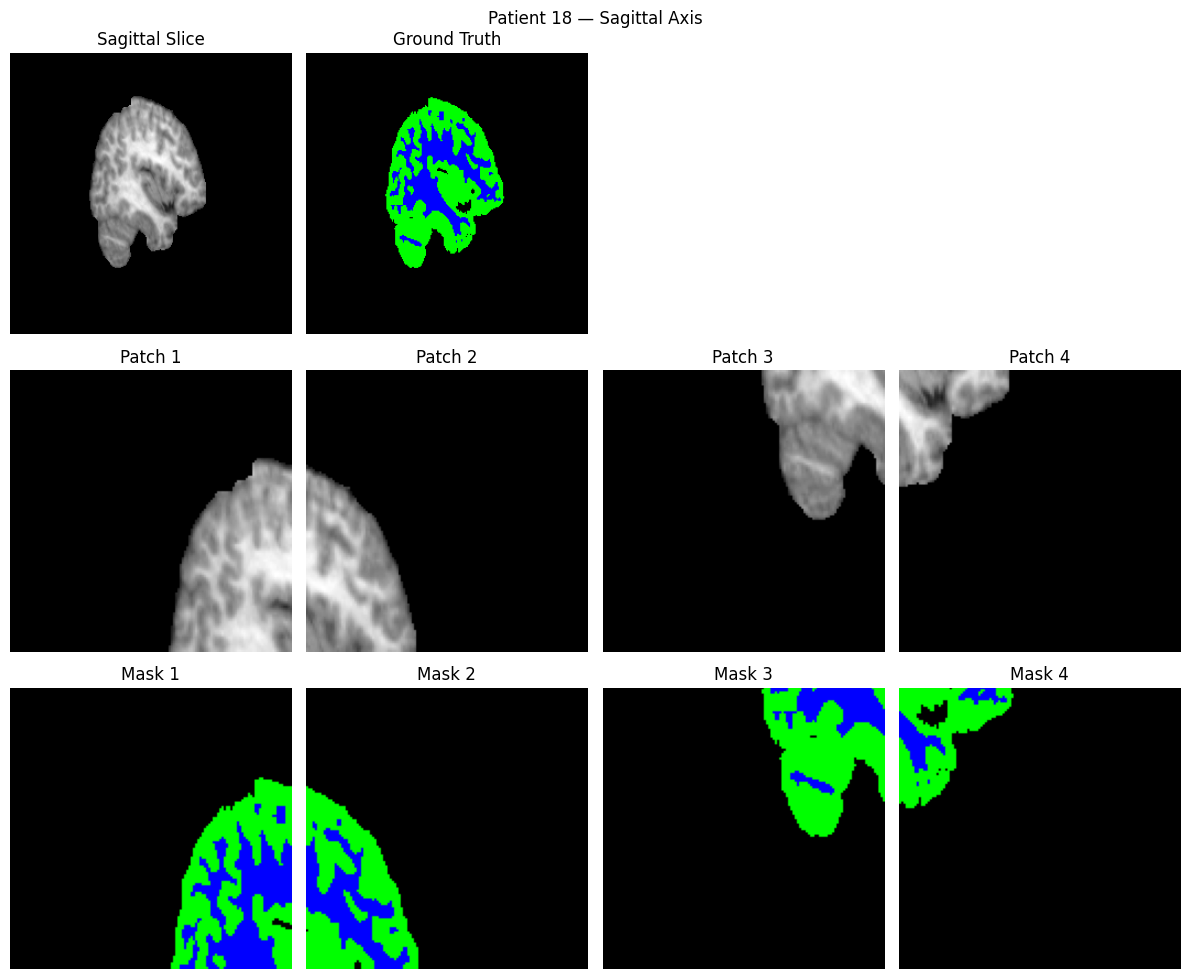

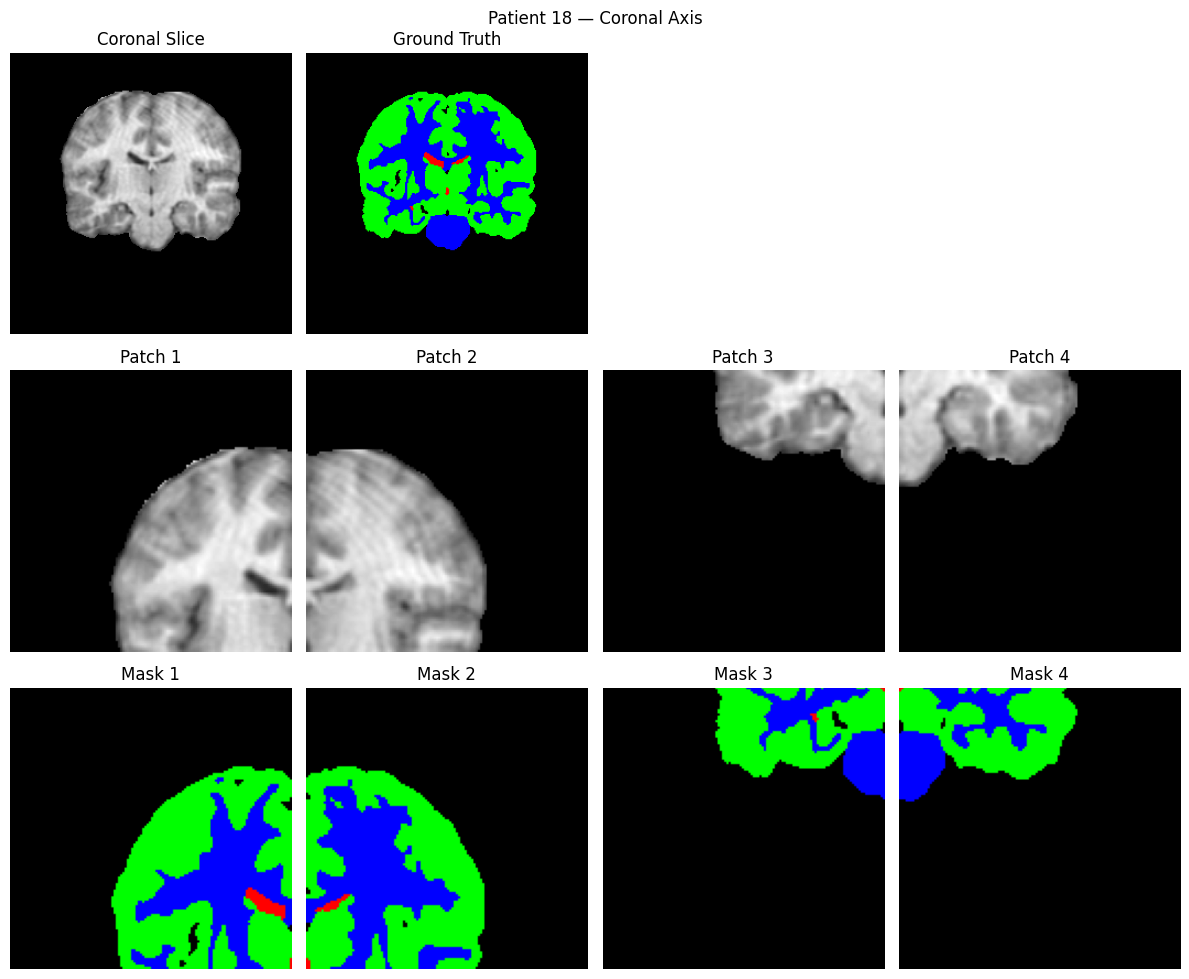

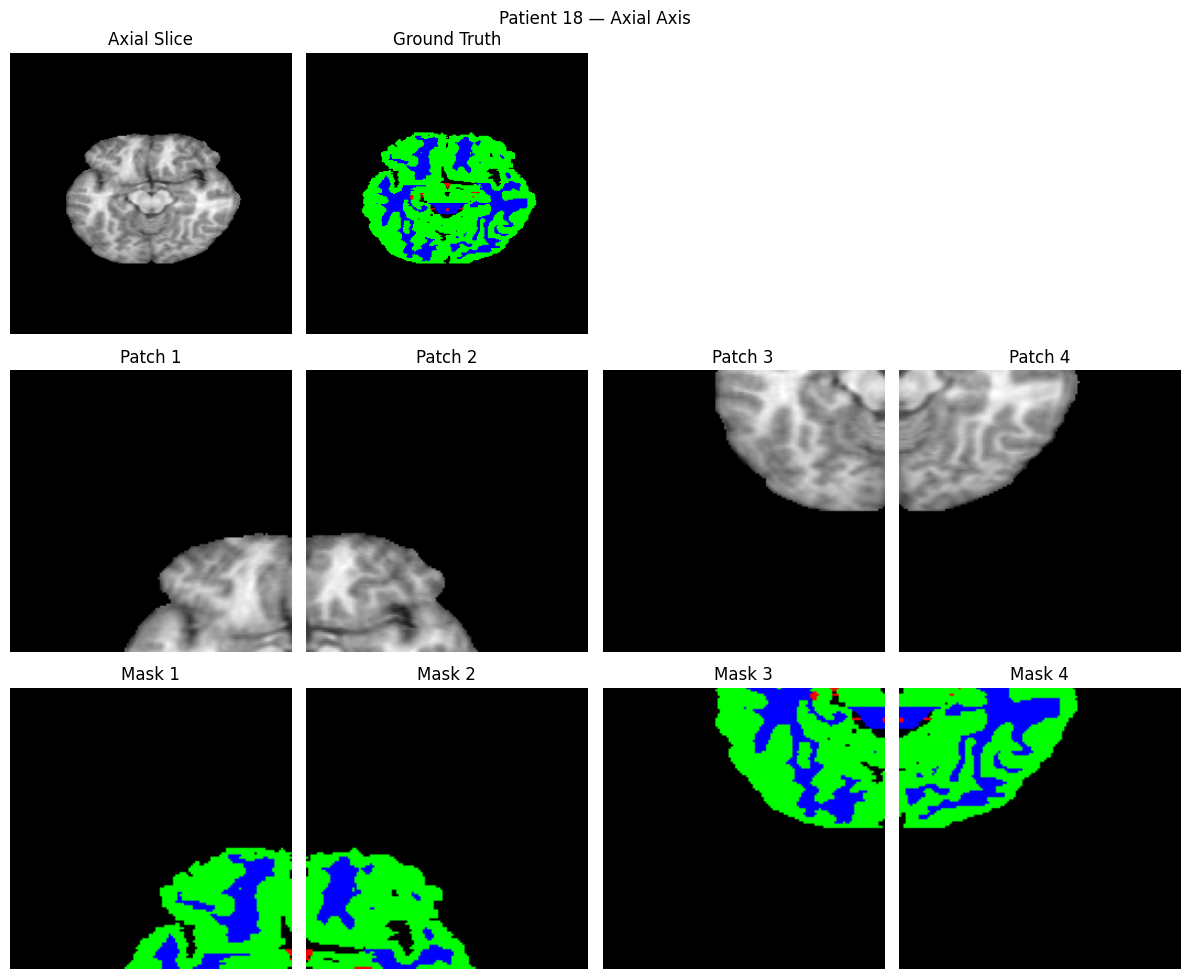

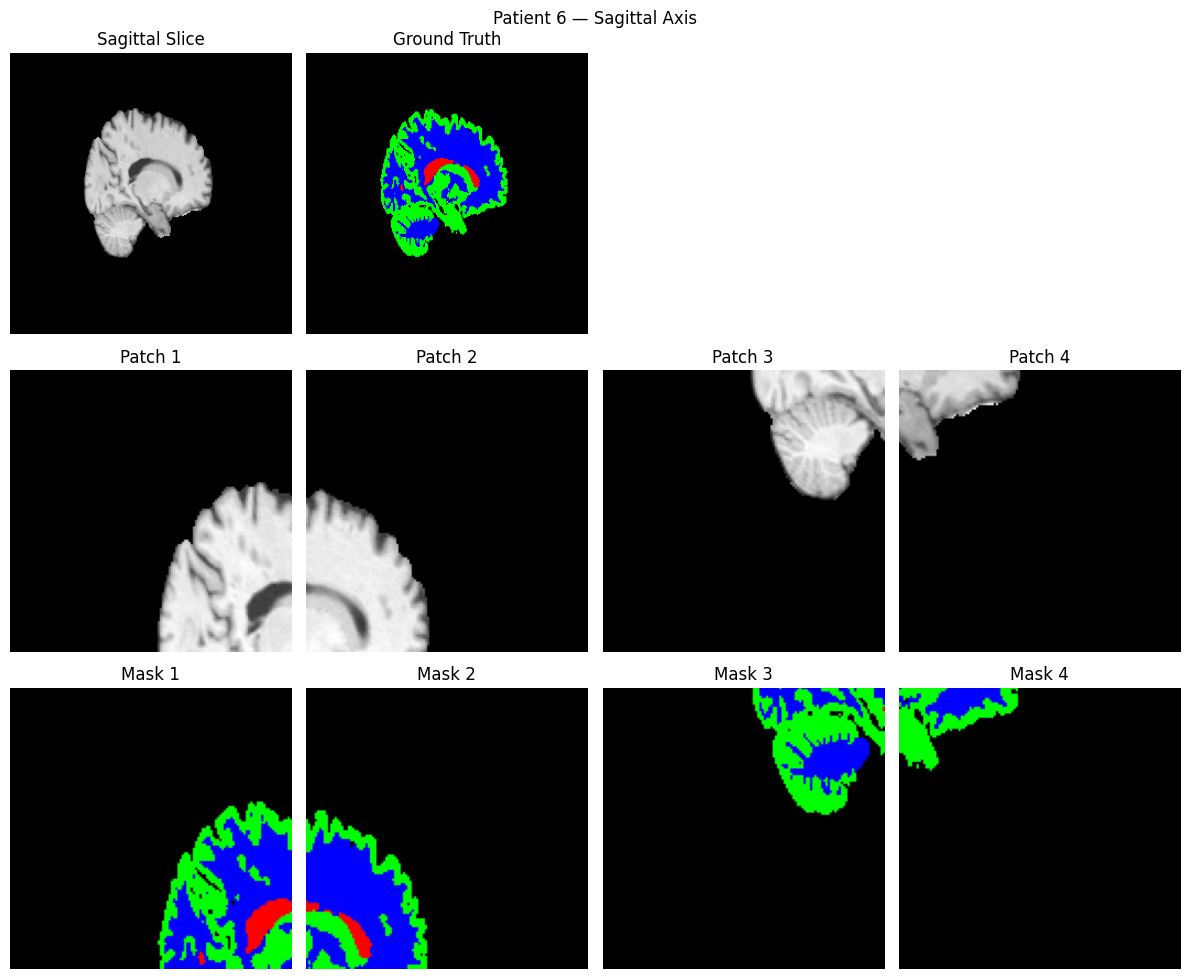

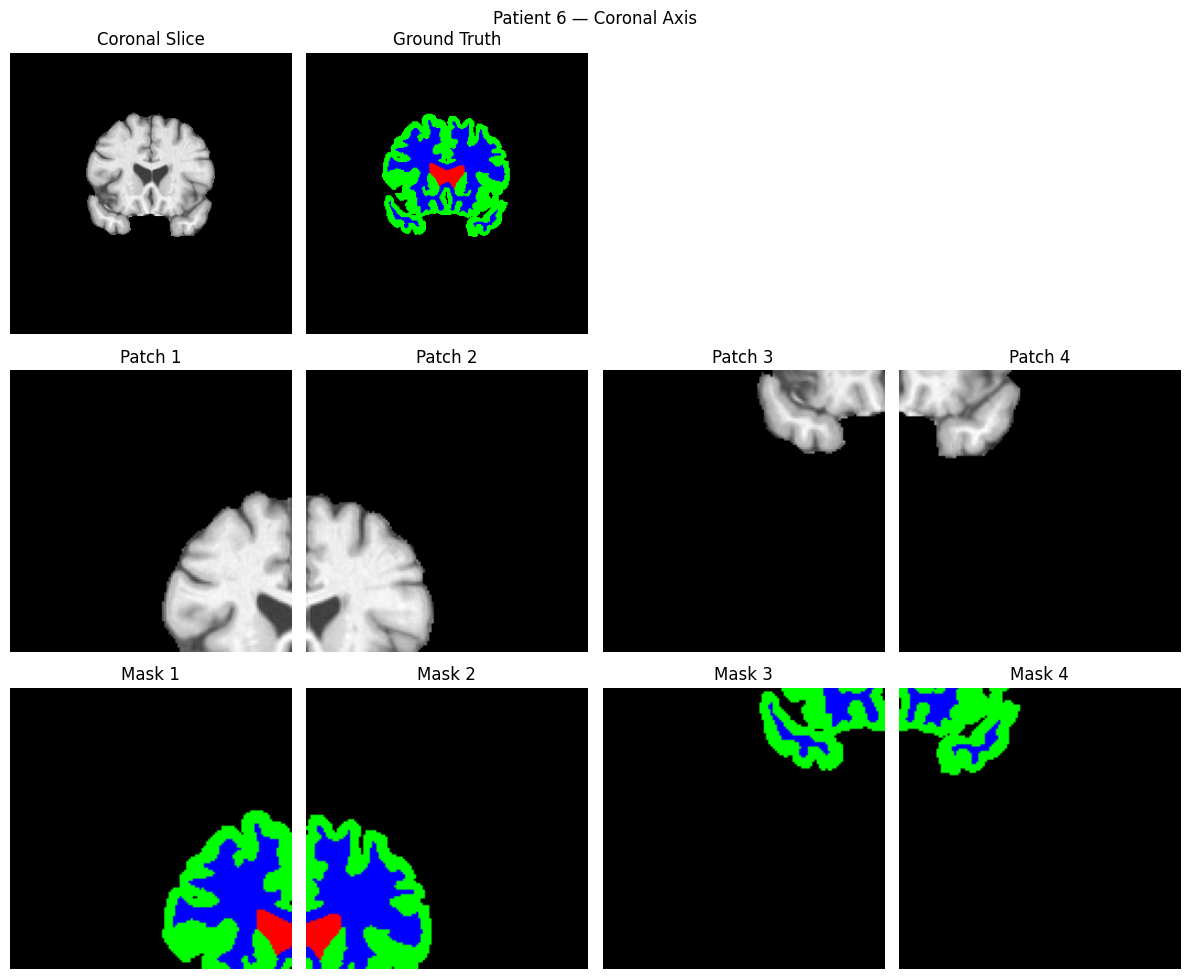

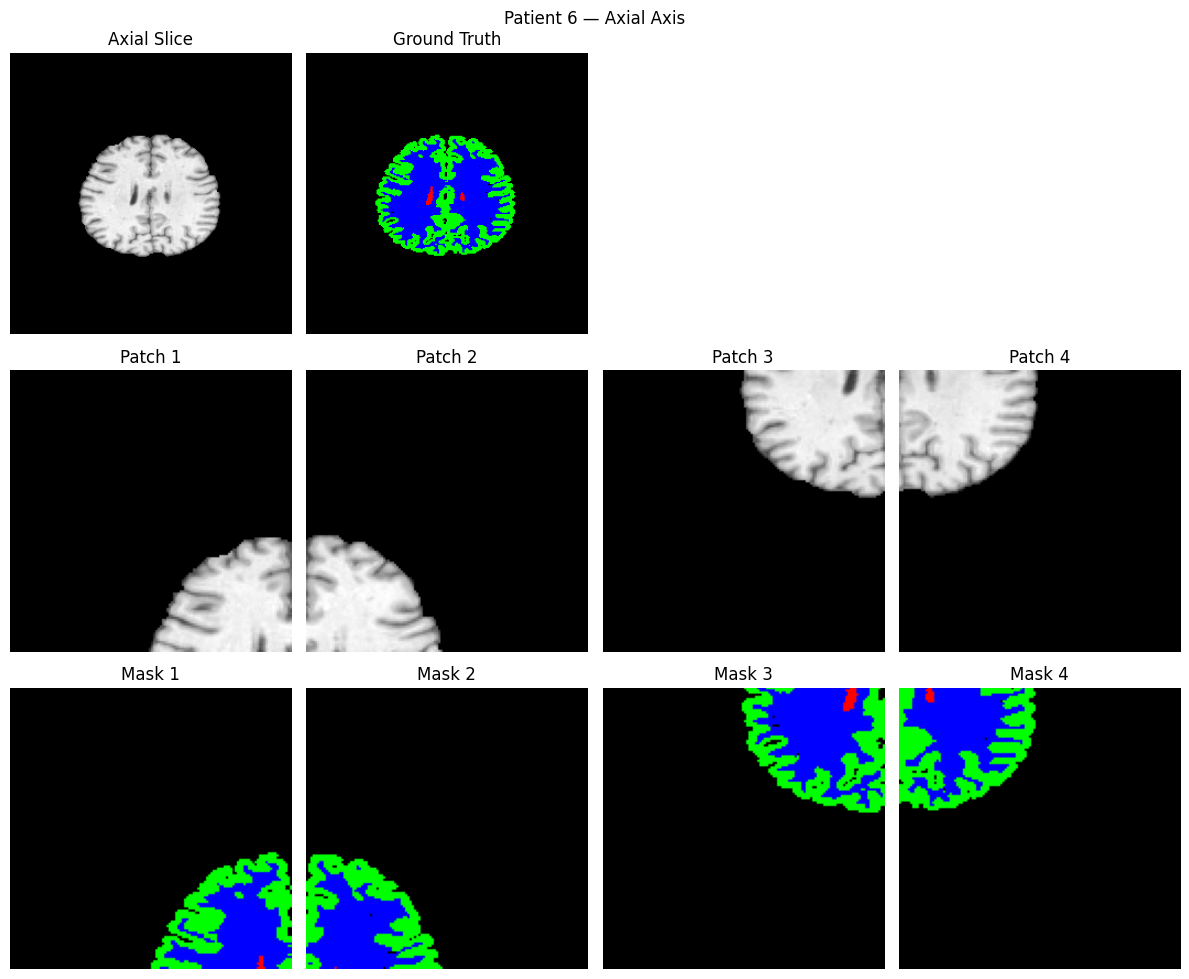

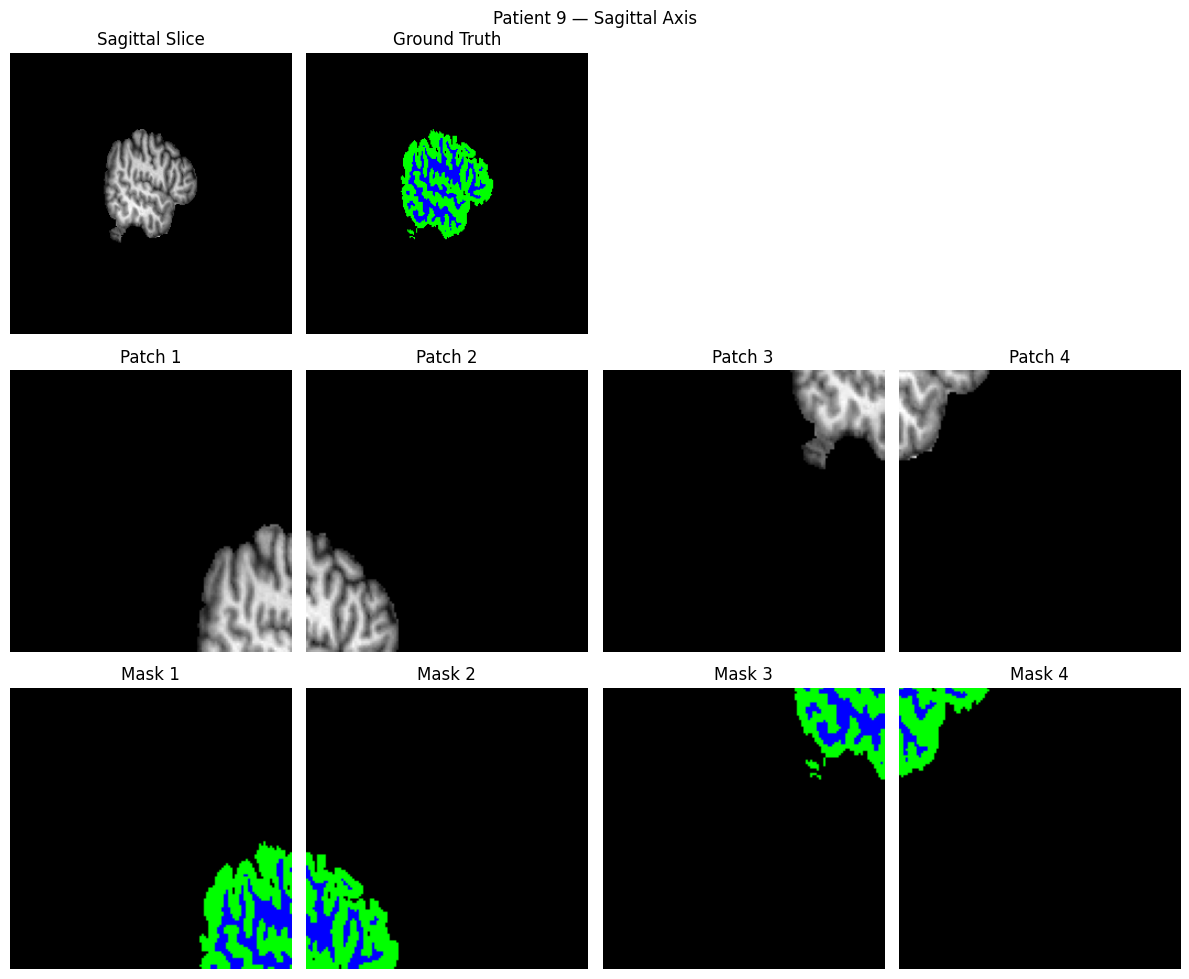

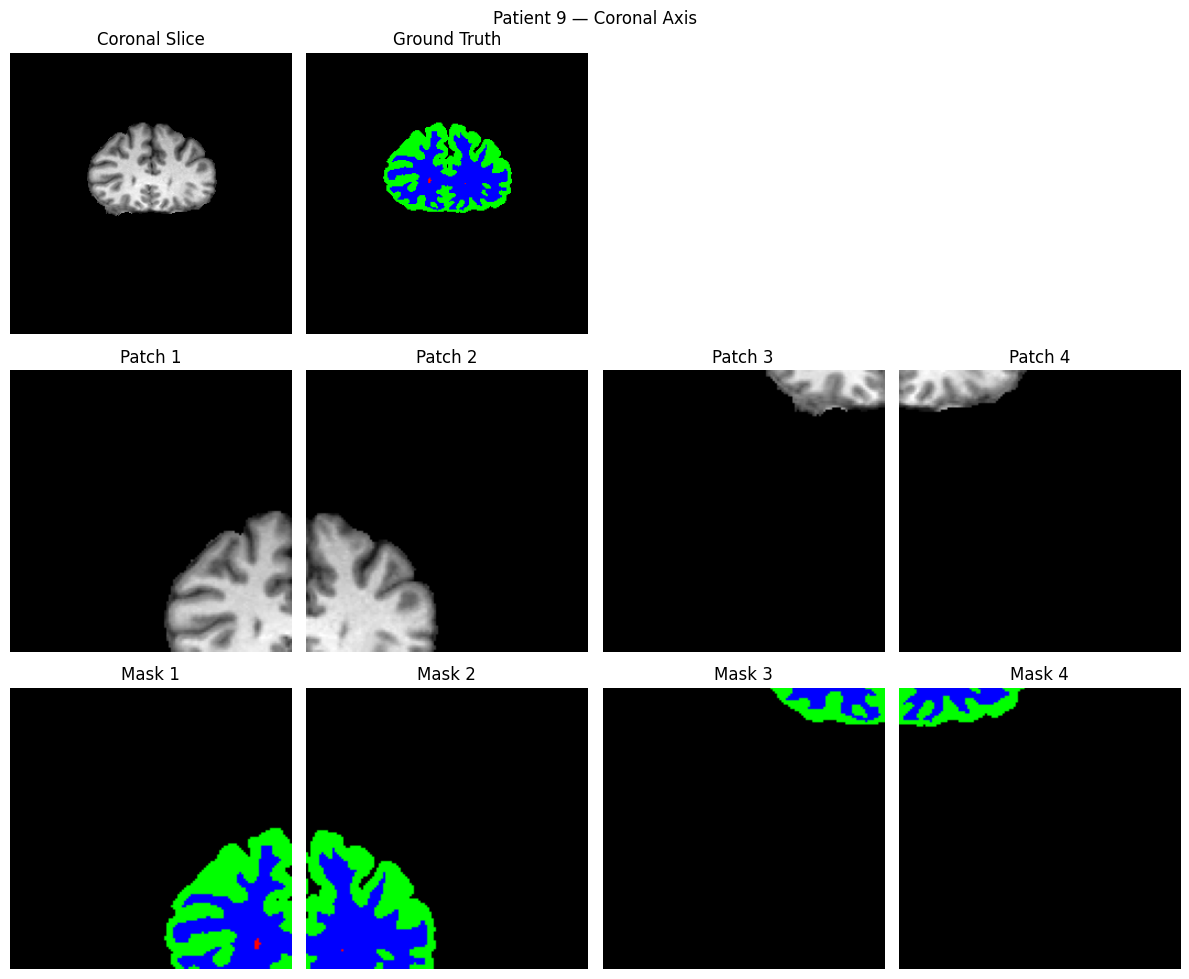

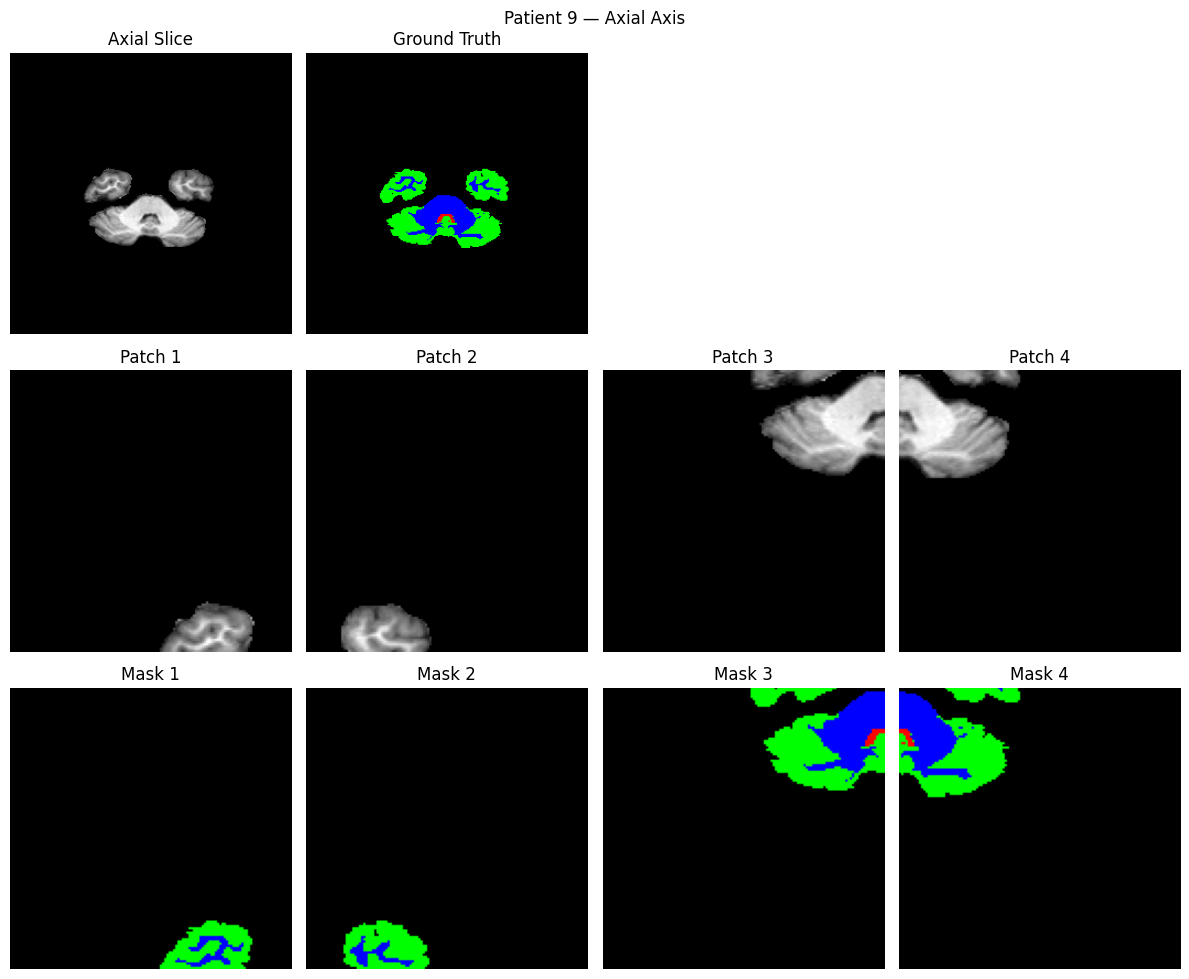

In [54]:
volumes, segmentations = load_ibsr_file_paths(DATA_ROOT)

selected_patients = random.sample(range(len(volumes)), NUM_PATIENTS)

for idx in selected_patients:
    visualize_patient_slices(
        volumes[idx],
        segmentations[idx],
        patient_id=idx + 1
    )

## Metric Computation

In [ ]:
class SegmentationMetrics:
    
    def __init__(self, num_classes: int, eps = 1e-7):
        self.num_classes = num_classes
        self.eps = eps
        self.reset()

    def reset(self):
        self.tp = torch.zeros(self.num_classes, dtype=torch.float64)
        self.fp = torch.zeros(self.num_classes, dtype=torch.float64)
        self.fn = torch.zeros(self.num_classes, dtype=torch.float64)

    @torch.no_grad()
    def update(self, logits: torch.Tensor, targets: torch.Tensor):
        preds = torch.argmax(logits, dim=1)

        for c in range(self.num_classes):
            pred_c = (preds == c)
            target_c = (targets == c)

            self.tp[c] += torch.sum(pred_c & target_c).item()
            self.fp[c] += torch.sum(pred_c & (~target_c)).item()
            self.fn[c] += torch.sum((~pred_c) & target_c).item()

    def compute(self):
        dice = (2 * self.tp) / (2 * self.tp + self.fp + self.fn + self.eps)
        jaccard = self.tp / (self.tp + self.fp + self.fn + self.eps)
        precision = self.tp / (self.tp + self.fp + self.eps)
        recall = self.tp / (self.tp + self.fn + self.eps)

        return {
            "dice": dice,
            "jaccard": jaccard,
            "precision": precision,
            "recall": recall
        }


## Define the model structure and training phase

In [74]:
NUM_CLASSES = 4
CLASS_NAMES = {0: "Background", 1: "CSF", 2: "GM", 3: "WM"}

In [ ]:
class Conv1x1Block(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)

class Conv3x3Block(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)

class DenseDoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels, dense_in_channels, use_1x1=True):
        super().__init__()
        ConvLayer = Conv1x1Block if use_1x1 else Conv3x3Block
        self.conv_first = ConvLayer(in_channels + dense_in_channels, out_channels)
        self.conv_second = ConvLayer(in_channels + dense_in_channels + out_channels, out_channels)

    def forward(self, dense_input, x):
        x_combined = torch.cat([dense_input, x], dim=1)
        x = self.conv_first(x_combined)
        x = torch.cat([x, x_combined], dim=1)
        x = self.conv_second(x)
        return x

class MNetSegmentation(nn.Module):
    def __init__(self, input_channels=1, num_classes=4):
        super().__init__()
        self.channel_sizes = [64, 128, 256, 512]

        self.max_pool = nn.MaxPool2d(2)
        self.upsample = nn.Upsample(scale_factor=2, mode="nearest")

        self.encoder_block1a = Conv1x1Block(input_channels, self.channel_sizes[0])
        self.encoder_block1b = Conv1x1Block(self.channel_sizes[0] + input_channels, self.channel_sizes[0])
        self.encoder_block2 = DenseDoubleConv(self.channel_sizes[0], self.channel_sizes[1], input_channels, use_1x1=True)
        self.encoder_block3 = DenseDoubleConv(self.channel_sizes[1], self.channel_sizes[2], input_channels, use_1x1=True)
        self.encoder_block4 = DenseDoubleConv(self.channel_sizes[2], self.channel_sizes[3], input_channels, use_1x1=True)

        self.bottleneck_block = Conv3x3Block(self.channel_sizes[3], self.channel_sizes[3])

        self.decoder_block3 = DenseDoubleConv(self.channel_sizes[3], self.channel_sizes[2], self.channel_sizes[2], use_1x1=False)
        self.decoder_block2 = DenseDoubleConv(self.channel_sizes[2], self.channel_sizes[1], self.channel_sizes[1], use_1x1=False)
        self.decoder_block1 = DenseDoubleConv(self.channel_sizes[1], self.channel_sizes[0], self.channel_sizes[0], use_1x1=False)

        self.output_conv = nn.Conv2d(sum(self.channel_sizes), num_classes, kernel_size=1)

    def forward(self, x):
        dense_level1 = x
        dense_level2 = self.max_pool(dense_level1)
        dense_level3 = self.max_pool(dense_level2)
        dense_level4 = self.max_pool(dense_level3)

        enc1 = self.encoder_block1a(x)
        enc1 = self.encoder_block1b(torch.cat([enc1, dense_level1], dim=1))
        x = self.max_pool(enc1)

        enc2 = self.encoder_block2(dense_level2, x)
        x = self.max_pool(enc2)

        enc3 = self.encoder_block3(dense_level3, x)
        x = self.max_pool(enc3)

        enc4 = self.encoder_block4(dense_level4, x)

        bottleneck_output = self.bottleneck_block(enc4)
        x = self.upsample(bottleneck_output)

        dec3 = self.decoder_block3(enc3, x)
        x = self.upsample(dec3)

        dec2 = self.decoder_block2(enc2, x)
        x = self.upsample(dec2)

        dec1 = self.decoder_block1(enc1, x)

        fusion_up3 = self.upsample(bottleneck_output)
        fusion_up2 = self.upsample(torch.cat([dec3, fusion_up3], dim=1))
        fusion_up1 = self.upsample(torch.cat([dec2, fusion_up2], dim=1))

        x = torch.cat([dec1, fusion_up1], dim=1)
        output = self.output_conv(x)
        return output

def lecun_initialize(module):
    if isinstance(module, nn.Conv2d):
        fan_in, _ = nn.init._calculate_fan_in_and_fan_out(module.weight)
        std = math.sqrt(1.0 / fan_in)
        nn.init.normal_(module.weight, mean=0.0, std=std)
        if module.bias is not None:
            nn.init.zeros_(module.bias)



In [76]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = MNetSegmentation(
    input_channels=1,
    num_classes=NUM_CLASSES   
).to(device)

model.apply(lecun_initialize)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-4, momentum=0.9)

In [81]:
num_trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
num_nontrainable_params = sum(p.numel() for p in model.parameters() if not p.requires_grad)

print("Trainable parameters:", num_trainable_params)
print("Non-trainable parameters:", num_nontrainable_params)

Trainable parameters: 8479620
Non-trainable parameters: 0


In [ ]:
train_loader = DataLoader(
    train_data,
    batch_size=1,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_data,
    batch_size=1,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

num_epochs = 10

train_losses = []
val_losses = []

dice_history = {c: [] for c in range(NUM_CLASSES)}

for epoch in range(1, num_epochs + 1):

    model.train()
    running_loss = 0.0

    for images, masks in train_loader:
        images = images.to(device)    
        masks = masks.to(device)     

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, masks)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)

    model.eval()
    val_running_loss = 0.0

    metrics = SegmentationMetrics(num_classes=NUM_CLASSES)
    metrics.reset()

    with torch.no_grad():
        for images, masks in val_loader:
            images = images.to(device)
            masks = masks.to(device)

            logits = model(images)
            loss = criterion(logits, masks)

            val_running_loss += loss.item()

            metrics.update(
                logits.detach().cpu(),
                masks.detach().cpu()
            )

    epoch_val_loss = val_running_loss / len(val_loader)
    val_losses.append(epoch_val_loss)

    results = metrics.compute()

    for c in range(NUM_CLASSES):
        dice_history[c].append(results["dice"][c].item())

    macro_dice = results["dice"][1:].mean().item()
    macro_jaccard = results["jaccard"][1:].mean().item()
    macro_precision = results["precision"][1:].mean().item()
    macro_recall = results["recall"][1:].mean().item()

    print(f"Epoch {epoch:02d}/{num_epochs}")
    print(f"  Train Loss: {epoch_train_loss:.6f}")
    print(f"  Val   Loss: {epoch_val_loss:.6f}")

    for c in range(NUM_CLASSES):
        print(
            f"  {CLASS_NAMES[c]:>10s} | "
            f"Dice={results['dice'][c]:.4f}  "
            f"IoU={results['jaccard'][c]:.4f}  "
            f"Prec={results['precision'][c]:.4f}  "
            f"Rec={results['recall'][c]:.4f}"
        )

    print(f"  Macro Dice (no background): {macro_dice:.4f}")
    print(f"  Macro Jaccard (no background): {macro_jaccard:.4f}")
    print(f"  Macro Precision (no background): {macro_precision:.4f}")
    print(f"  Macro Recall (no background): {macro_recall:.4f}")
    print("-" * 70)




Epoch 01/10
  Train Loss: 0.177552
  Val   Loss: 0.053330
  Background | Dice=0.9991  IoU=0.9982  Prec=0.9984  Rec=0.9998
         CSF | Dice=0.5680  IoU=0.3966  Prec=0.7385  Rec=0.4614
          GM | Dice=0.8404  IoU=0.7247  Prec=0.8195  Rec=0.8623
          WM | Dice=0.8069  IoU=0.6762  Prec=0.8148  Rec=0.7991
  Macro Dice (no background): 0.7384
  Macro Jaccard (no background): 0.5992
  Macro Precision (no background): 0.7909
  Macro Recall (no background): 0.7076
----------------------------------------------------------------------
Epoch 02/10
  Train Loss: 0.062797
  Val   Loss: 0.056425
  Background | Dice=0.9993  IoU=0.9985  Prec=0.9986  Rec=0.9999
         CSF | Dice=0.5808  IoU=0.4093  Prec=0.7824  Rec=0.4618
          GM | Dice=0.7684  IoU=0.6239  Prec=0.8608  Rec=0.6939
          WM | Dice=0.7735  IoU=0.6307  Prec=0.6567  Rec=0.9409
  Macro Dice (no background): 0.7076
  Macro Jaccard (no background): 0.5546
  Macro Precision (no background): 0.7666
  Macro Recall (no backg

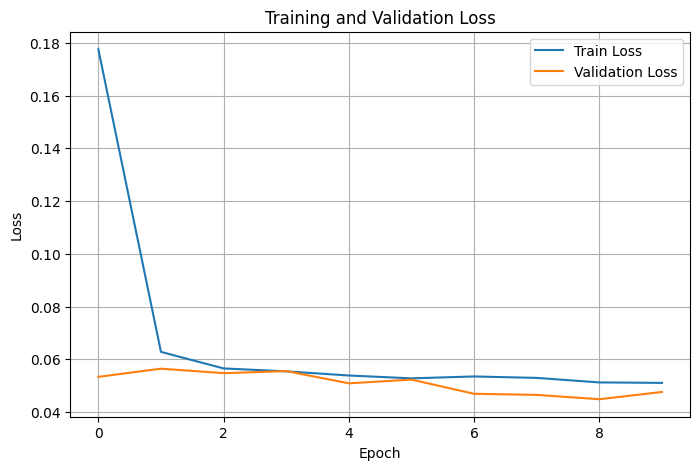

In [78]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

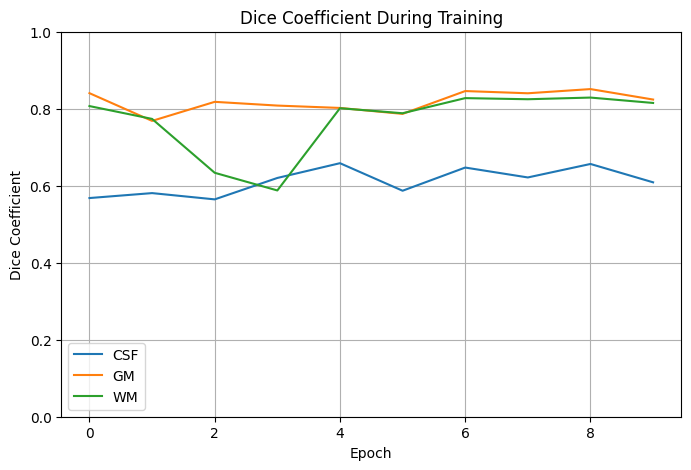

In [79]:
important_classes = ["CSF", "GM", "WM"]
important_indices = [
    idx for idx, name in CLASS_NAMES.items()
    if name in important_classes
]

plt.figure(figsize=(8, 5))
for idx in important_indices:
    plt.plot(
        dice_history[idx],
        label=f"{CLASS_NAMES[idx]}"
    )

plt.xlabel("Epoch")
plt.ylabel("Dice Coefficient")
plt.title("Dice Coefficient During Training")
plt.ylim(0.0, 1.0)
plt.legend()
plt.grid(True)
plt.show()

## Visualization of results

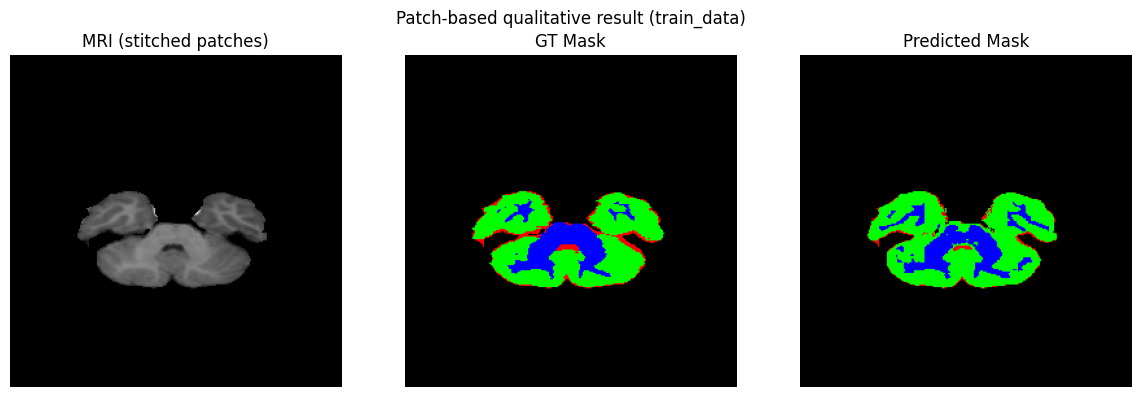

In [ ]:
start_idx = random.randint(0, len(train_data) - 4)
start_idx = start_idx - (start_idx % 4)

patches = []
masks = []

for i in range(4):
    img, mask = train_data[start_idx + i]
    patches.append(img.squeeze(0).numpy())   
    masks.append(mask.numpy())               

def predict_4_patches(patches, model, device):
    model.eval()
    preds = []

    with torch.no_grad():
        for patch in patches:
            x = torch.tensor(patch, dtype=torch.float32) \
                     .unsqueeze(0).unsqueeze(0).to(device)

            logits = model(x)                 
            pred = torch.argmax(logits, dim=1)
            preds.append(pred.squeeze(0).cpu().numpy())

    return preds
preds = predict_4_patches(patches, model, device)

def stitch_2x2(patch_list):
    top = np.concatenate([patch_list[0], patch_list[1]], axis=1)
    bottom = np.concatenate([patch_list[2], patch_list[3]], axis=1)
    return np.concatenate([top, bottom], axis=0)
img_256  = stitch_2x2(patches)
gt_256   = stitch_2x2(masks)
pred_256 = stitch_2x2(preds)
def colorize_mask(mask):
    colors = np.array([
        [0, 0, 0],        
        [255, 0, 0],      
        [0, 255, 0],      
        [0, 0, 255],     
    ])
    return colors[mask]
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(img_256, cmap="gray")
plt.title("MRI (stitched patches)")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(colorize_mask(gt_256))
plt.title("GT Mask")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(colorize_mask(pred_256))
plt.title("Predicted Mask")
plt.axis("off")

plt.suptitle("Patch-based qualitative result (train_data)")
plt.tight_layout()
plt.show()
